# **ML PROJECT - EEG PD**
## Imports & Configuration

In [ ]:
!pip install -q mne
!pip install captum
!pip install scikit-posthocs

  Using cached scikit_posthocs-0.12.0-py3-none-any.whl.metadata (5.8 kB)
Using cached scikit_posthocs-0.12.0-py3-none-any.whl (36 kB)


In [ ]:
import os
import warnings
import copy
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.lines import Line2D

from scipy.optimize import linear_sum_assignment
from scipy.stats import mode, pearsonr, entropy, pointbiserialr, zscore
import scipy.stats as stats
from scipy.spatial import ConvexHull
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LinearRegression
from scipy.optimize import linear_sum_assignment
from sklearn.manifold import TSNE
from scipy.integrate import trapezoid
from scipy.signal import spectrogram
import scikit_posthocs as sp

import mne
from mne.time_frequency import psd_array_welch
from sklearn.neighbors import NearestNeighbors
from random import sample

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
	silhouette_score, davies_bouldin_score, calinski_harabasz_score,
	adjusted_rand_score, normalized_mutual_info_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
	classification_report, accuracy_score, roc_curve, auc, roc_auc_score, make_scorer, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, GroupKFold, cross_validate, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC

import torch
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset, WeightedRandomSampler
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from collections import Counter

from imblearn.over_sampling import SMOTE

from captum.attr import IntegratedGradients


In [ ]:
plt.ioff()
RANDOM_STATE = 42

All models are fixed with a random seed to ensure reproducibility. Importantly, the analysis deliberately relies on **multiple clustering algorithms and dimensionality reduction techniques** to avoid conclusions driven by a single method.

# 1. DATASET DISCOVERY & SANITY CHECKS

The dataset consists of **resting-state EEG recordings** from Parkinson’s disease patients and healthy controls. The overarching goal of the unsupervised analysis is **not classification**, but rather to characterize the **intrinsic geometry** of EEG feature space.

## Mount & Sanity checks

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/ds004584")

Mounted at /content/drive


In [ ]:
set_files = sorted(DATA_ROOT.glob("sub-*/eeg/*.set"))
print(f"Found {len(set_files)} EEG recordings")

Found 149 EEG recordings


In [ ]:
# Load one example recording (sanity check only)
example_file = set_files[0]
raw = mne.io.read_raw_eeglab(example_file, preload=False, verbose=False)

print("Sampling frequency:", raw.info["sfreq"])
print("Number of channels:", len(raw.ch_names))
print("Duration (seconds):", raw.n_times / raw.info["sfreq"])
print("First 10 channel names:", raw.ch_names[:10])

Sampling frequency: 500.0
Number of channels: 63
Duration (seconds): 281.66
First 10 channel names: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9']


Using matplotlib as 2D backend.


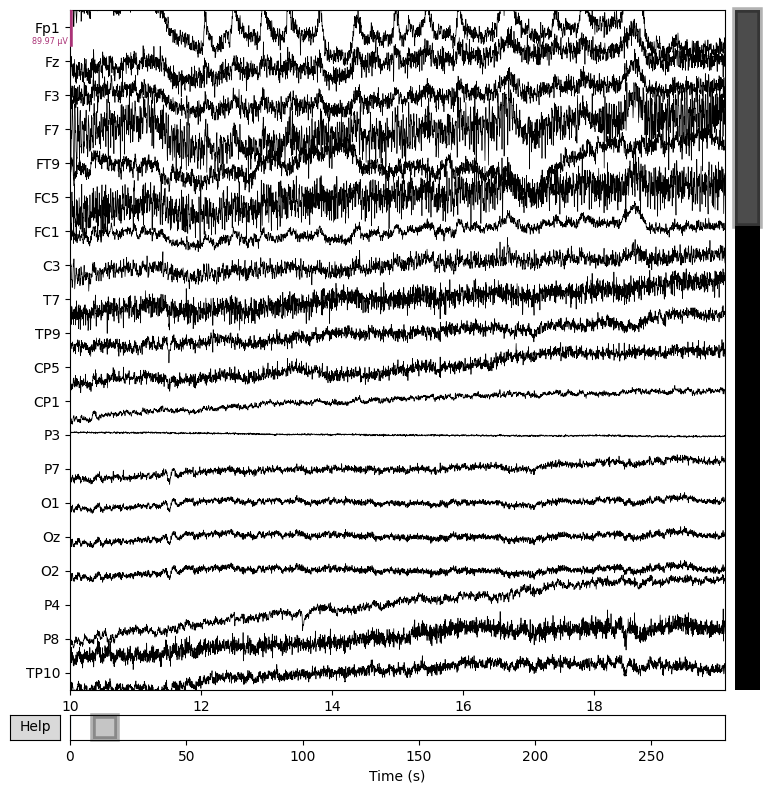

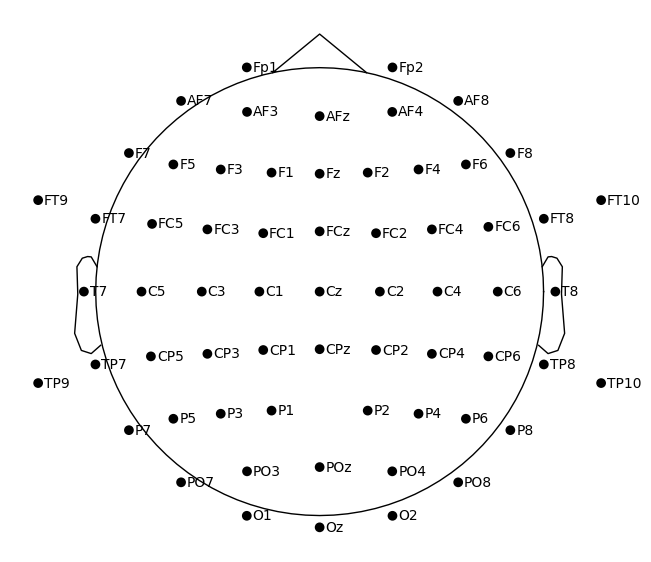

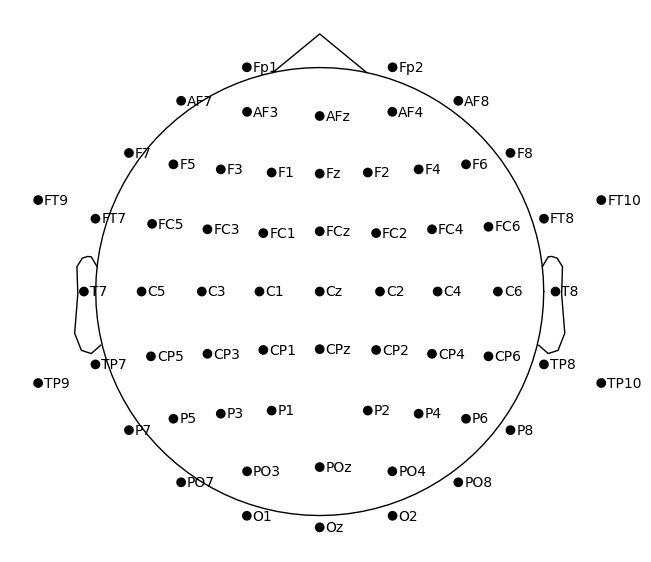

In [ ]:
# Visual inspection (not used later)
raw.plot(n_channels=20, start=10, duration=10, scalings="auto")
raw.plot_sensors(show_names=True)

Plotting power spectral density (dB=True).


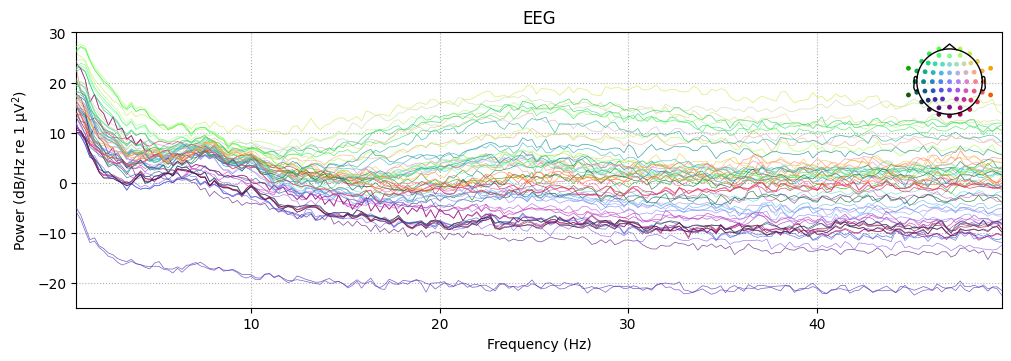

In [ ]:
psd = raw.compute_psd(method="welch", fmin=0.5, fmax=50, verbose=False)
psd.plot(dB=True)

## Participants, labels and cognitive scores

We ask whether latent structure emerges naturally from the data, and if so, whether this structure aligns with disease diagnosis or clinical variables such as age, cognition (MOCA), or motor severity (UPDRS).

In [ ]:
participants = pd.read_csv(
    DATA_ROOT / "participants_clin_cog.csv"#,sep="\t"
)

cognitive_cols = ['NIH FICAT', 'NIH DCCST', 'NIH PCPST', 'NIH PSMT','NIH PVT']

# Keep only rows where all cognitive tests are not NaN
participants = participants.dropna(subset=cognitive_cols).copy()

subject_ids_cog = participants["participant_id"].tolist()

participants["label_num"] = participants["GROUP"].map(
    {"Control": 0, "PD": 1}
)

participants["GROUP"].value_counts()

,count
GROUP,
PD,92
Control,46


In [ ]:
subject_ids = [file.parts[-3] for file in set_files]
valid_subjects = [subj for subj in subject_ids if subj in participants["participant_id"].values]

subject_ids_cog = set(valid_subjects)

set_files = sorted(
    f for f in DATA_ROOT.glob("sub-*/eeg/*.set")
    if f.parts[f.parts.index("eeg") - 1] in subject_ids_cog
)

In [ ]:
age = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"AGE"].values
moca = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"MOCA"].values
updrs = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"UPDRS"].values
nih_ficat = participants.loc[participants["participant_id"].isin([f.parts[-3] for f in set_files]),"NIH FICAT"].values


# Sanity check
if len(age) == len(valid_subjects):
  print("AGE vector shape:", age.shape)
else:
  raise ValueError("AGE vector length mismatch")

y_true = participants.set_index("participant_id").loc[valid_subjects, "label_num"].values

AGE vector shape: (138,)


Labels are loaded here for bookkeeping and post hoc evaluation only.
They are not used in feature construction or clustering.

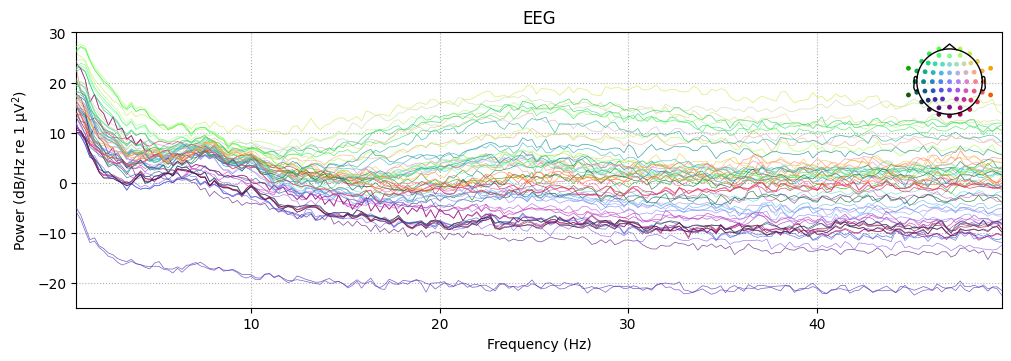

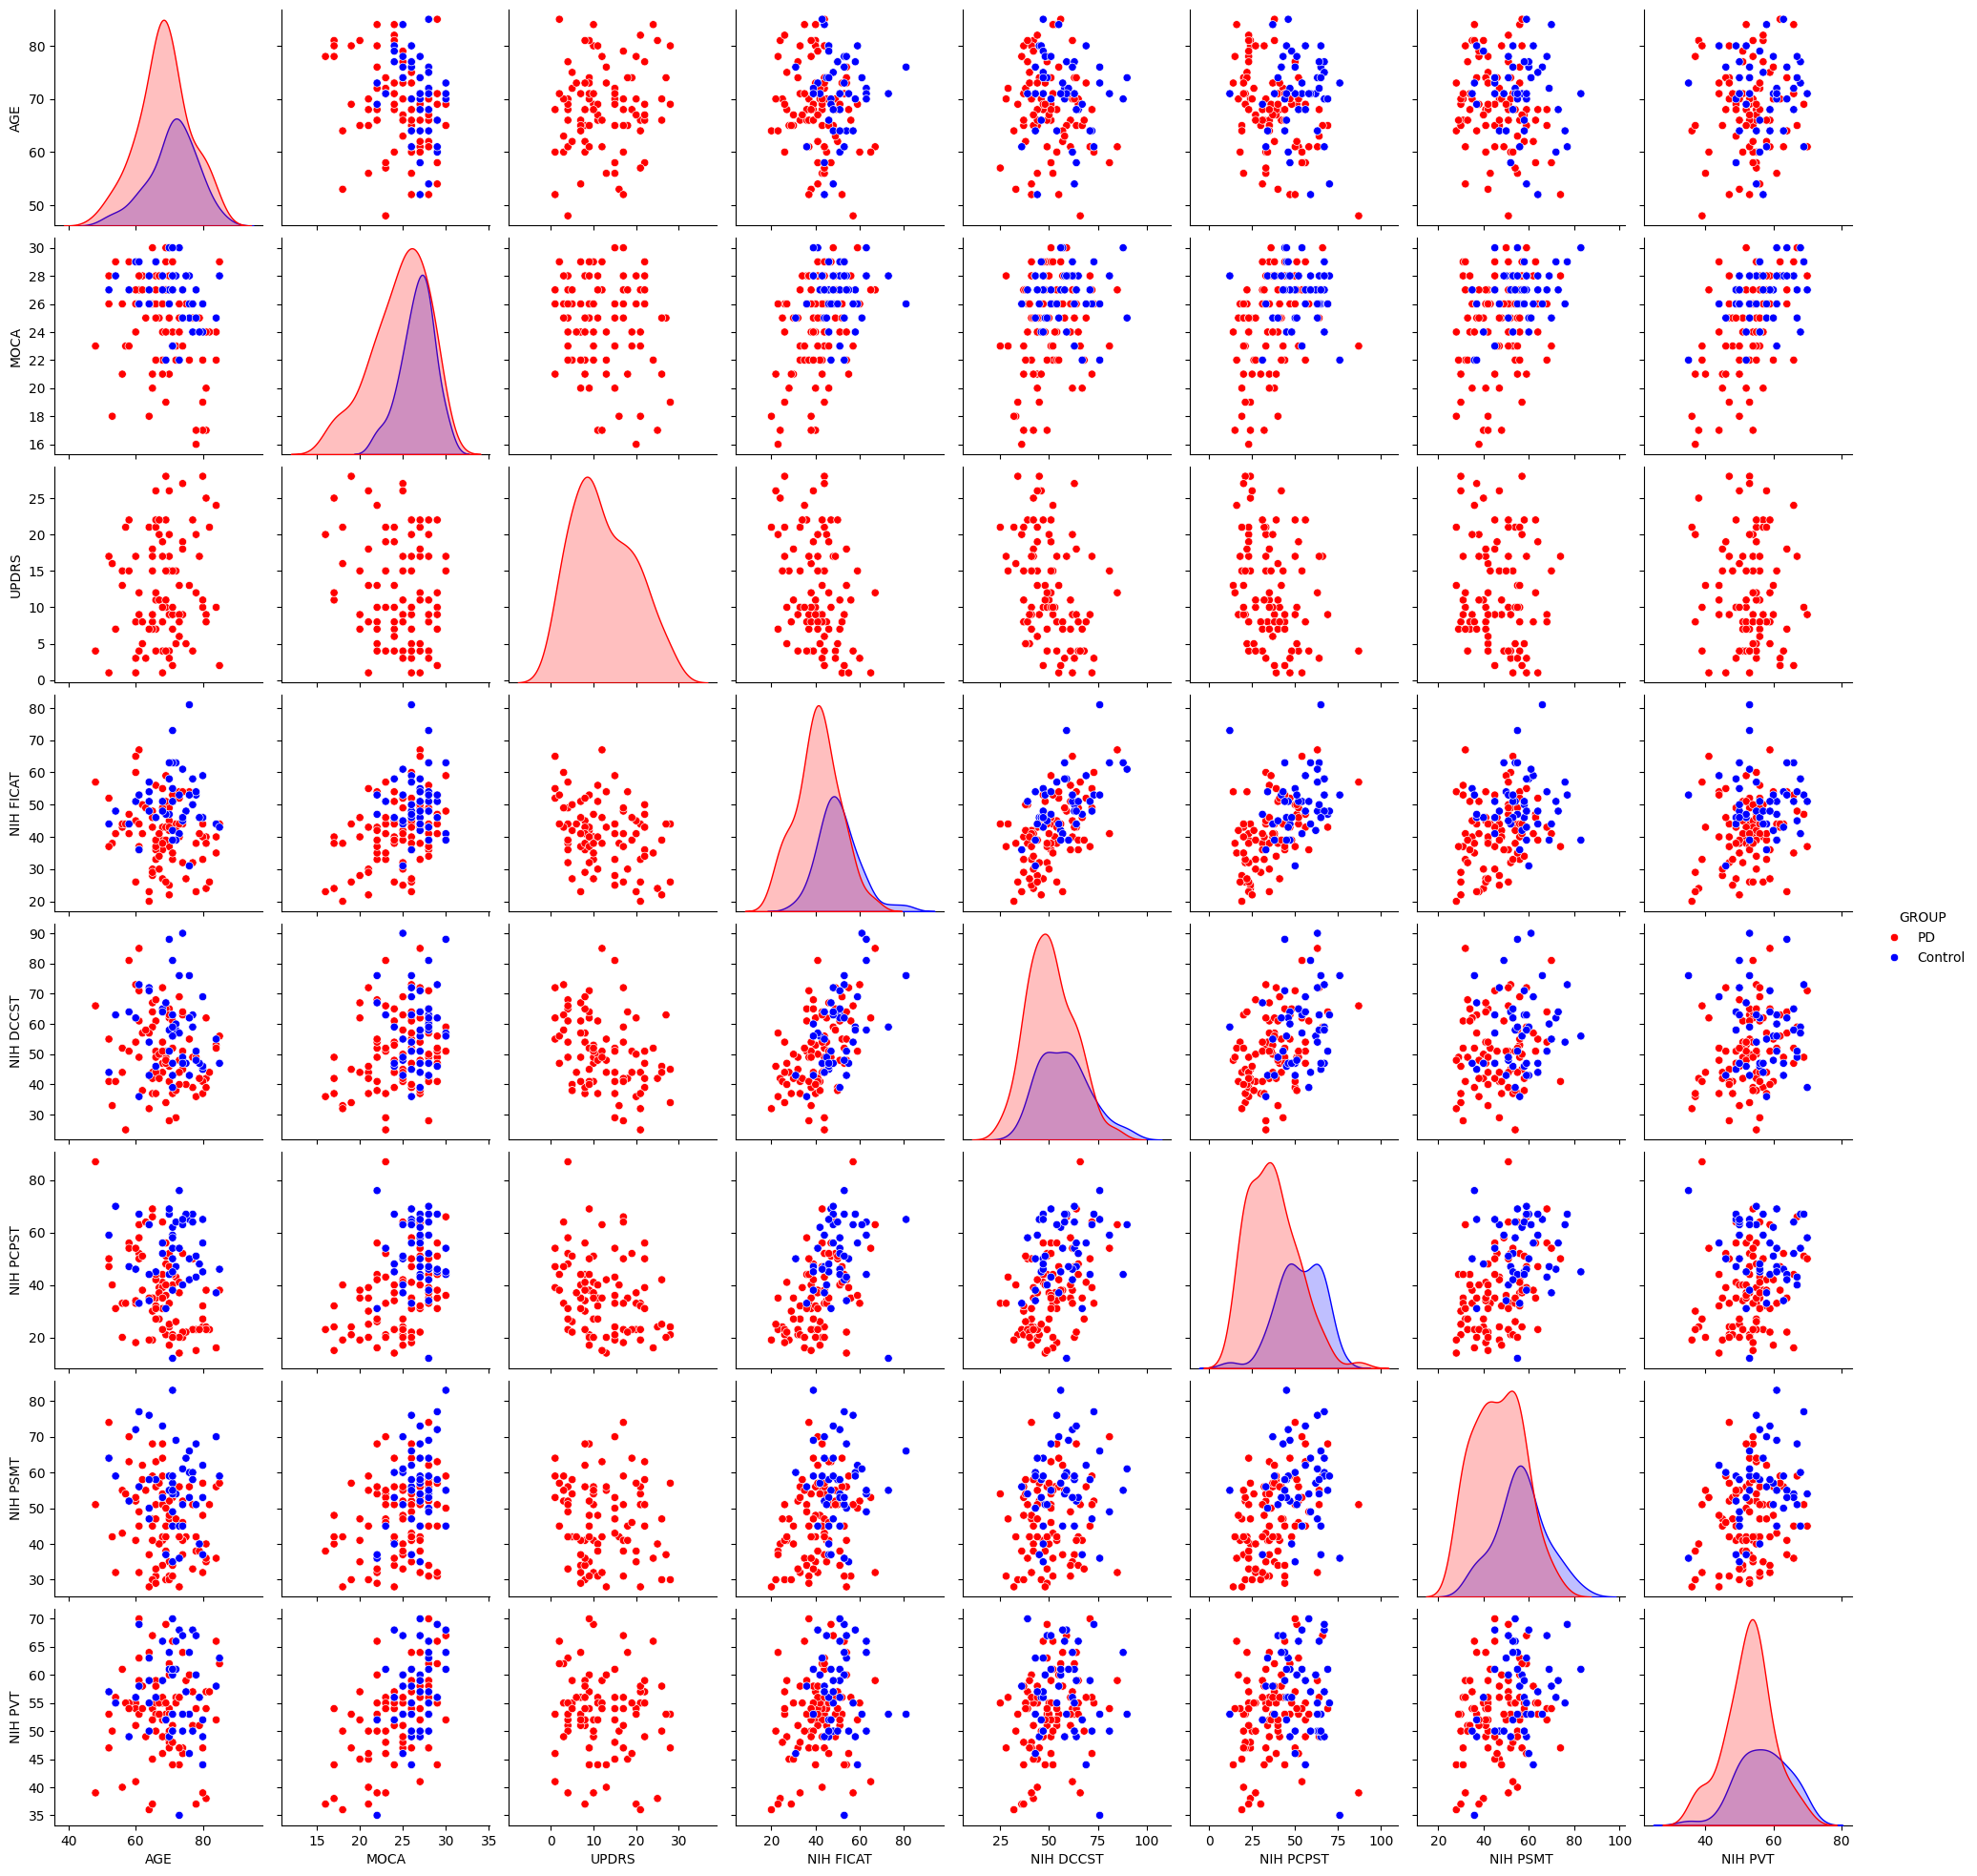

In [ ]:
subject_info = participants.copy()
sns.pairplot(subject_info[['AGE', 'MOCA', 'UPDRS', 'NIH FICAT', 'NIH DCCST', 'NIH PCPST', 'NIH PSMT','NIH PVT','GROUP']], hue="GROUP", palette={"PD":'Red' , "Control": 'Blue'})

plt.show()

## Common channels

In [ ]:
def load_eeg(file_path: Path) -> mne.io.Raw:
  # Load using mne
  return mne.io.read_raw_eeglab(
    file_path,
    preload=True,
    verbose=False
  )

In [ ]:
# Determine common channel set (intersection across subjects)
channel_sets = []

for file in set_files:
  raw = load_eeg(file)
  channel_sets.append(set(raw.ch_names))

common_channels = sorted(set.intersection(*channel_sets))
print(f"Using {len(common_channels)} common channels")

Using 60 common channels


In [ ]:
selected_channels = ['P8', 'PO7', 'CP1', 'CP2', 'P6', 'O2', 'P4', 'F4']

## Global cognitive score

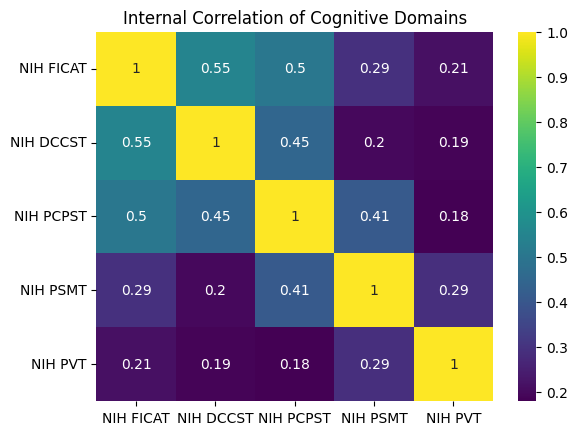

In [ ]:
# Check how well the NIH scores correlate with each other
internal_corr = participants[cognitive_cols].corr()

sns.heatmap(internal_corr, annot=True, cmap='viridis')
plt.title("Internal Correlation of Cognitive Domains")
plt.show()

FICAT, DCCST, and PCPST are all strongly inter-correlated ($0.45$ to $0.55$). These three tests (Inhibitory Control, Cognitive Flexibility, and Processing Speed) are clearly moving together. They represent a "Frontal-Executive" core.PSMT and PVT have much weaker ties to that core (dropping as low as $0.18$). These measure Memory and Vocabulary/Vision, which are likely being preserved or affected differently in the group.

In [ ]:
# Mean & Std of the Healthy Controls ONLY
controls = participants[participants['GROUP'] == 'Control']
core_tests = ['NIH FICAT', 'NIH DCCST', 'NIH PCPST']

control_means = controls[core_tests].mean()
control_stds = controls[core_tests].std()

# Z-scores for EVERYONE based on those Control Norms
z_scores = (participants[core_tests] - control_means) / control_stds
participants['Executive_Composite'] = z_scores.mean(axis=1)

def normative_map(z):
    if z < -1.0: return 2 # Impaired
    if z < 0.0:  return 1 # Standard
    return 0              # Preserved

participants['cog_tier'] = participants['Executive_Composite'].apply(normative_map)
participants['cog_binary'] = (participants['cog_tier'] == 2).astype(int)


In [ ]:

# 1 = Impaired (Tier 2), 0 = Not Impaired (Tiers 0 & 1)
participants['cog_binary'] = participants['cog_tier'].apply(lambda x: 1 if x == 2 else 0)

print(f"-  CLINICAL LABEL SUMMARY (N={len(participants)})  -")
print("\nGroup Breakdown of Tiers (0=Impaired, 1=Standard, 2=Preserved):")
print(participants.groupby('GROUP')['cog_tier'].value_counts().unstack().fillna(0).astype(int))

print()
print("Binary Distribution (1=Impaired, 0=Not_Impaired):")
binary_counts = participants.groupby('GROUP')['cog_binary'].value_counts().unstack().fillna(0).astype(int)
binary_counts.columns = ['Not_Impaired (0)', 'Impaired (1)']
print(binary_counts)

-  CLINICAL LABEL SUMMARY (N=138)  -

Group Breakdown of Tiers (0=Impaired, 1=Standard, 2=Preserved):
cog_tier   0   1   2
GROUP               
Control   20  23   3
PD        12  36  44

Binary Distribution (1=Impaired, 0=Not_Impaired):
         Not_Impaired (0)  Impaired (1)
GROUP                                  
Control                43             3
PD                     48            44


To establish a biologically grounded ground-truth for cognitive status, participants were categorized using a normative-referenced composite score targeting the frontal-executive domain. Recognizing that Inhibitory Control (FICAT), Cognitive Flexibility (DCCST), and Processing Speed (PCPST) exhibited strong inter-correlation ($r = 0.45$ to $0.55$), an Executive Composite was calculated. This was achieved by transforming raw scores into Z-scores based exclusively on the distribution of the Healthy Control cohort ($N=46$). By using the healthy population as the baseline yardstick, we ensured that "Impairment" was defined not by arbitrary clusters, but by significant deviation from neurotypical performance. Specifically, a threshold of $Z < -1.0$ (representing the bottom 15% of healthy performance) was used to define Clinical Impairment (Tier 0), while $Z \ge 0$ identified Preserved function (Tier 2). This rigorous stratification provides a stable clinical anchor for the subsequent unsupervised EEG clustering, allowing us to test whether natural brain-wave patterns respect these established clinical boundaries.

# 2. CORE PROCESSING UTILITIES + FEATURE CONSTRUCTION

## Feature construction

In [ ]:
def compute_psd(raw, fmin=0.5, fmax=40.0):
  data = raw.get_data()  # shape (n_channels, n_times)
  sfreq = raw.info["sfreq"] # Sampling freq (Hz) is required to map samples to physical frequencies

  # PSD using Welch’s method - avg periodograms over overlapping windows, reducing variance and making it well-suited for resting-state EEG
  psd, freqs = psd_array_welch(data, sfreq=sfreq, fmin=fmin, fmax=fmax,
                                n_fft=2048, average="mean", verbose=False)
  return psd, freqs

def get_band_features(psd, freqs, channels, bands):
  values, names = [], []
  for ch_idx, ch_name in enumerate(channels):
    for b_name, (fmin, fmax) in bands.items():
      idx = np.where((freqs >= fmin) & (freqs < fmax))[0]
      val = psd[ch_idx, idx].mean()
      values.append(val)
      names.append(f"{ch_name}_{b_name}")
  return np.array(values), names

Multiple feature representations are constructed to probe EEG structure at different levels of abstraction. This includes high-dimensional spectral representations as well as biologically motivated low-frequency summaries. Importantly, features are constructed **per channel × band**, preserving spatial information and enabling interpretability of latent axes.

If we focus on known PD-sensitive frequencies, does diagnostic separation improve?
Prior work identified the 0.5–12 Hz range as maximally discriminative between PD and control subjects, spanning delta, theta, and low-alpha bands known to be abnormal in PD.

LEAPD bandpower features were included as a hypothesis-driven, disease-optimized representation, complementary to generic spectral features. This allows us to assess whether unsupervised structure aligns more strongly with PD-specific spectral abnormalities or emerges independently of disease-informed feature design.

In [ ]:
LEAPD_BANDS = {
    "delta_leapd": (0.5, 4),
    "theta_leapd": (5, 8),
    "l_alpha_leapd": (9, 12)
}

Inclusion of a "sham band" for specificity control

In [ ]:
SHAM_BANDS = {
  "delta":(0.5, 4),
  "theta":(5, 8),
  "alpha":(9, 12),
  "beta":(13, 30), # Additoinal band for checking
}

In [ ]:
def construct_master_features(set_files, channel_list):
  # (one per subject)
  X_full_list = []
  X_low_list = []
  X_sham_list = []

  print(f"Starting processing for {len(set_files)} files...")

  for file in tqdm(set_files):
      try:
        raw = mne.io.read_raw_eeglab(file, preload=True, verbose=False)
        raw.pick(channel_list)

        # PSD once (0.5 to 40 Hz)
        psd, freqs = compute_psd(raw, fmin=0.5, fmax=40.0)

        # FULL PSD
        X_full_list.append(np.log10(psd.flatten() + 1e-12))

        # LOW FREQ (0.5-12Hz) + RATIOS
        # Band powers per channel
        bp_leapd, _ = get_band_features(psd, freqs, channel_list, LEAPD_BANDS)

        # Reshape to (Channels, Bands)
        bp_reshaped = bp_leapd.reshape(len(channel_list), -1)
        theta = bp_reshaped[:, 1] # Index 1 is Theta (5-8Hz)
        alpha = bp_reshaped[:, 2] # Index 2 is Alpha (9-12Hz)

        # TAR per channel
        tar_vals = theta / (alpha + 1e-12)
        # Global TAR (One value per subject)
        global_tar = np.mean(theta) / (np.mean(alpha) + 1e-12)

        # [24 bandpowers, 8 TARs, 1 Global TAR]
        low_freq_combined = np.hstack([bp_leapd, tar_vals, [global_tar]])
        X_low_list.append(low_freq_combined)

        # SHAM BAND
        bp_sham, _ = get_band_features(psd, freqs, channel_list, SHAM_BANDS)
        X_sham_list.append(bp_sham)

      except Exception as e:
        print(f"Error processing {file.name}: {e}")

  # Lists to final 2D NumPy arrays (Rows = Subjects, Cols = Features)
  return {
    "full_psd": np.array(X_full_list),
    "low_freq": np.array(X_low_list),
    "sham_band": np.array(X_sham_list)
  }



In [ ]:
FEATURES = construct_master_features(set_files, selected_channels)

print()
print("-  FINAL INTEGRITY CHECK  -")
for key, data in FEATURES.items():
  print(f"Set: {key} | Shape: {data.shape}")

Starting processing for 138 files...


100%|██████████| 138/138 [00:31<00:00,  4.39it/s]


-  FINAL INTEGRITY CHECK  -
Set: full_psd | Shape: (138, 1288)
Set: low_freq | Shape: (138, 33)
Set: sham_band | Shape: (138, 32)


In [ ]:
bands = ["Delta", "Theta", "L-Alpha"]

profile_cols = []

# First 24: Band powers (Channel_Band)
for ch in selected_channels:
    for b in bands:
        profile_cols.append(f"{ch}_{b}")

# Next 8: TAR per channel
for ch in selected_channels:
    profile_cols.append(f"{ch}_TAR")

# Final 1: Global TAR
profile_cols.append("Global_TAR")

# Verify the length matches your data columns (Should be 33)
print(f"Total Features: {len(profile_cols)}")

Total Features: 33


Sizes ok:

low_freq = $(8 \text{ channels} \times 3 \text{ bands}) + 8 \text{ per-channel TARs} + 1 \text{ Global TAR} = \mathbf{33}$

sham_band =  $(8 \text{ channels} \times 4 \text{ bands}) $ = 32

## Outlier Id

In [ ]:
# Use Isolation Forest to find subjects whose EEG 'shape' is weird
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE) # Top 5%
outlier_preds = iso.fit_predict(FEATURES["low_freq"])

# Identify who they are
outlier_indices = np.where(outlier_preds == -1)[0]
outlier_ids = [valid_subjects[i] for i in outlier_indices]

print(f"Detected {len(outlier_ids)} EEG outliers: {outlier_ids}")

Detected 7 EEG outliers: ['sub-002', 'sub-003', 'sub-014', 'sub-082', 'sub-087', 'sub-095', 'sub-115']


In [ ]:
keep_indices = [i for i, sub_id in enumerate(valid_subjects) if sub_id not in outlier_ids]

# Update  participants DataFrame
# This ensures our metadata stays in sync
participants = participants[participants['participant_id'].isin([valid_subjects[i] for i in keep_indices])].reset_index(drop=True)

# Update all feature matrices in dict
# We apply the keep_indices filter to every matrix (low_freq, sham, full)
for key in FEATURES:
    FEATURES[key] = FEATURES[key][keep_indices]

# Update master ID list to reflect the new set
subs_list = [valid_subjects[i] for i in keep_indices]

print(f"--- CLEANING COMPLETE ---")
print(f"Removed: {len(outlier_ids)} subjects.")
print(f"New total N: {len(participants)} (PD: {sum(participants['GROUP']=='PD')}, Control: {sum(participants['GROUP']=='Control')})")

--- CLEANING COMPLETE ---
Removed: 7 subjects.
New total N: 131 (PD: 86, Control: 45)


## Feature Engineering & Normalization

In [ ]:
participants_indexed = participants.set_index('participant_id')

y_binary = participants_indexed.loc[subs_list, 'cog_binary'].values

y_tiered = participants_indexed.loc[subs_list, 'cog_tier'].values

y_diag = participants_indexed.loc[subs_list, 'GROUP'].values

print(f"Labels defined for {len(y_binary)} subjects.")

Labels defined for 131 subjects.


In [ ]:
# Dict for scaled features to avoid label leakage
FEATURES_SCALED = {}
scaler = StandardScaler()

for key, matrix in FEATURES.items():
    # Fit and transform ONLY on the 131 clean subjects
    FEATURES_SCALED[key] = scaler.fit_transform(matrix)

# UNSUPERVISED LEARNING
ALIGNMENT ANALYSIS
Do clusters naturally form around PD status or Cognition?

## Dim reduction tSNE

In [ ]:
def diagnostic_pca_report(FEATURES_SCALED):
  pca_results = {}

  for name, X in FEATURES_SCALED.items():
    pca = PCA()
    pca.fit(X)

    # Calculate how many components to reach 90% variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1

    pca_results[name] = {
      "Total Features": X.shape[1],
      "Components for 90% Var": n_90,
      "Top 3 Variance": np.sum(pca.explained_variance_ratio_[:3])
    }

    # Optional: Print the report
    print(f"-  PCA Report: {name}  -")
    print(f"90% of variance is captured by {n_90} components")
    print(f"The first 3 components explain {pca_results[name]['Top 3 Variance']*100:.1f}% of data\n")

  return pd.DataFrame(pca_results).T

pca_report = diagnostic_pca_report(FEATURES_SCALED)

-  PCA Report: full_psd  -
90% of variance is captured by 13 components
The first 3 components explain 59.5% of data

-  PCA Report: low_freq  -
90% of variance is captured by 11 components
The first 3 components explain 63.3% of data

-  PCA Report: sham_band  -
90% of variance is captured by 12 components
The first 3 components explain 52.1% of data



The first 3 components of the feature construction based off the lower bands explain the most variance amongst the different constructions.

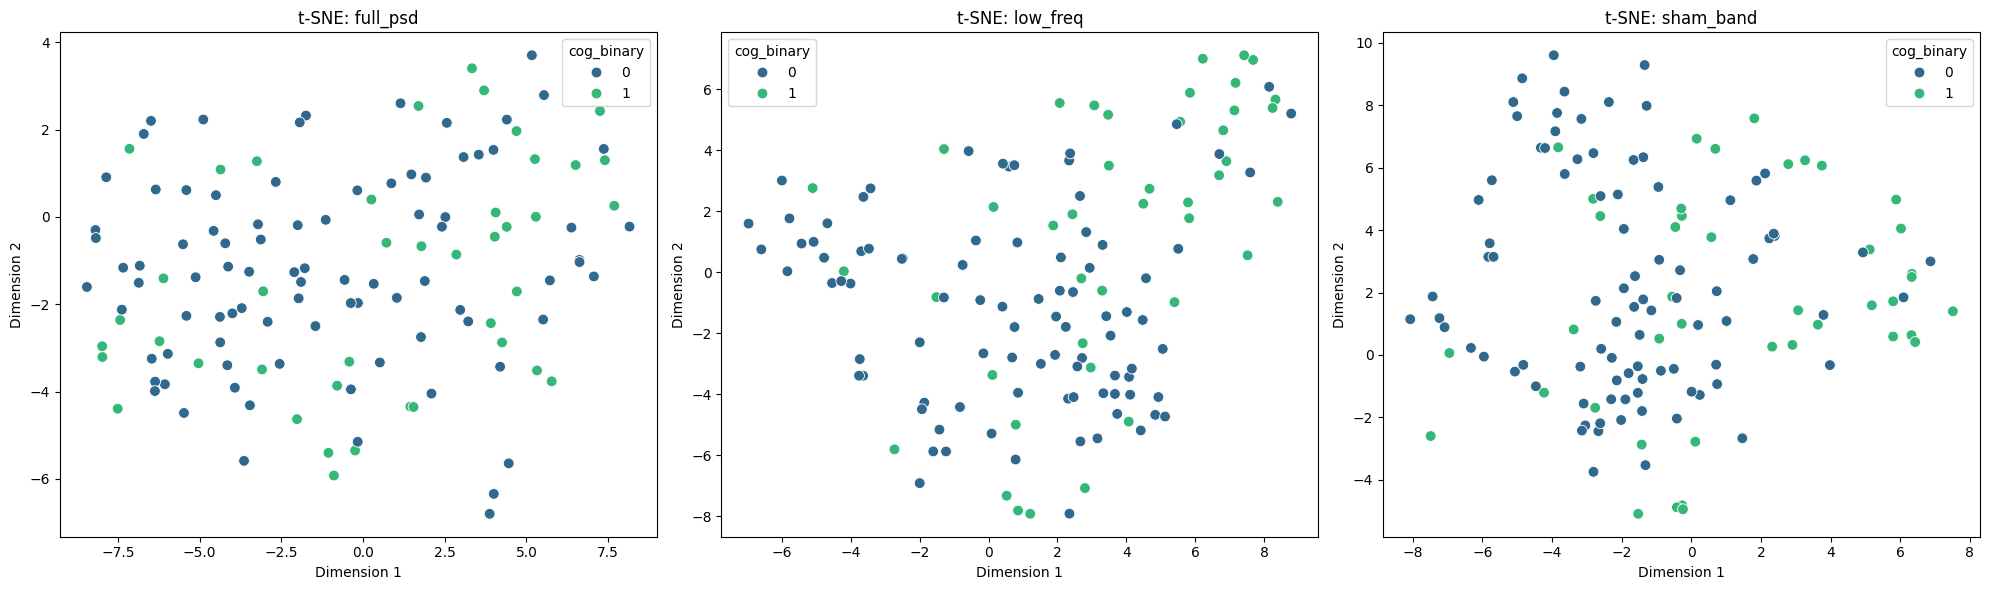

In [ ]:
def plot_tsne_comparison(FEATURES_SCALED, participants_df, subs_list, color_col = 'cog_binary'):
  fig, axes = plt.subplots(1, 3, figsize=(20, 6))

  df_idx = participants_df.set_index("participant_id").loc[subs_list]
  color_label = df_idx[color_col]

  for i, (name, X) in enumerate(FEATURES_SCALED.items()):
    # Perplexity ~30
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X)

    sns.scatterplot(
      x=X_embedded[:, 0], y=X_embedded[:, 1],
      hue=color_label, palette='viridis', ax=axes[i], s=60
    )
    axes[i].set_title(f"t-SNE: {name}")
    axes[i].set_xlabel("Dimension 1")
    axes[i].set_ylabel("Dimension 2")

  plt.tight_layout()
  plt.show()

plot_tsne_comparison(FEATURES_SCALED, participants, subs_list, 'cog_binary')

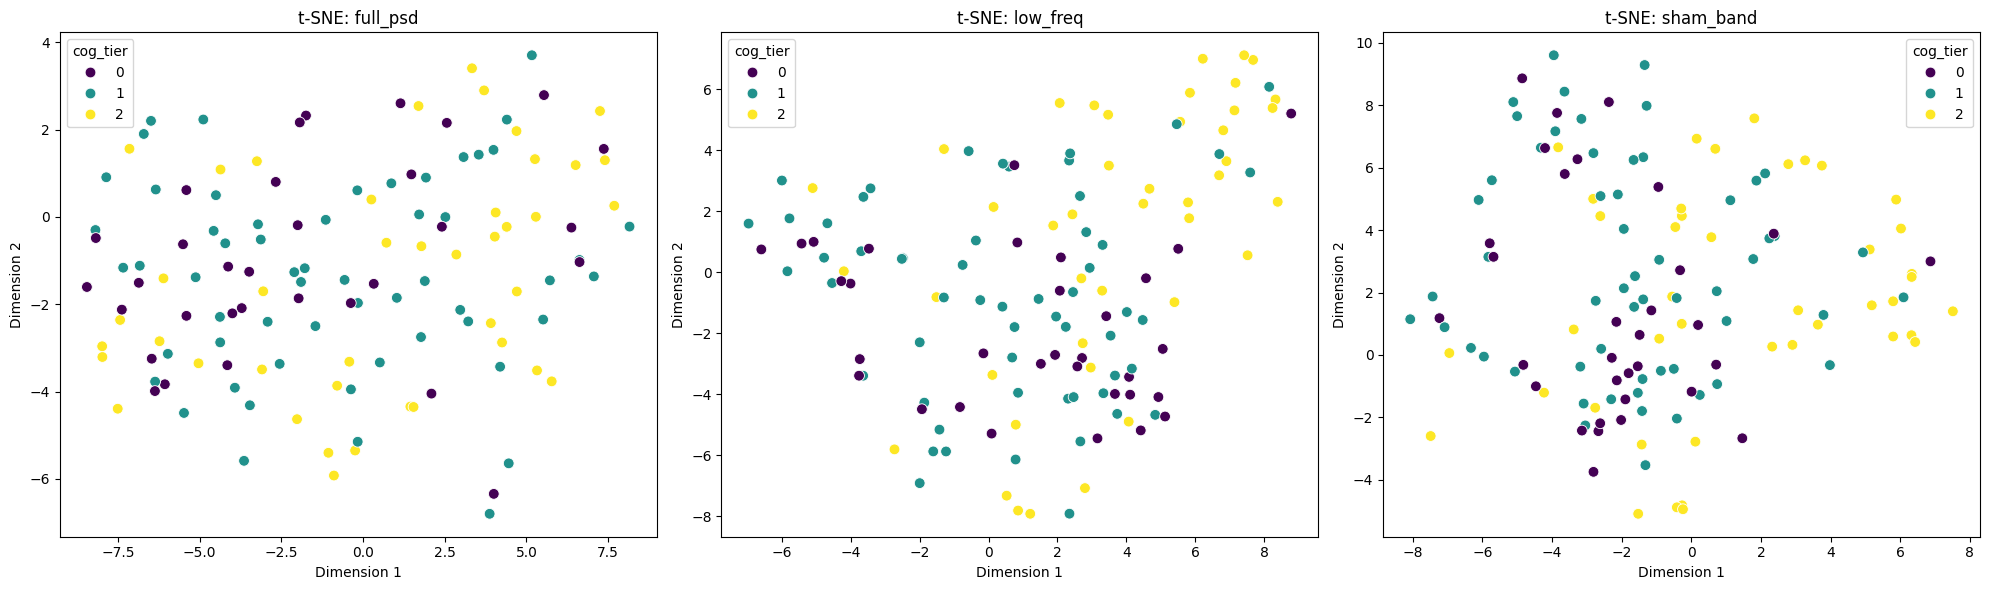

In [ ]:
plot_tsne_comparison(FEATURES_SCALED, participants, subs_list, 'cog_tier')

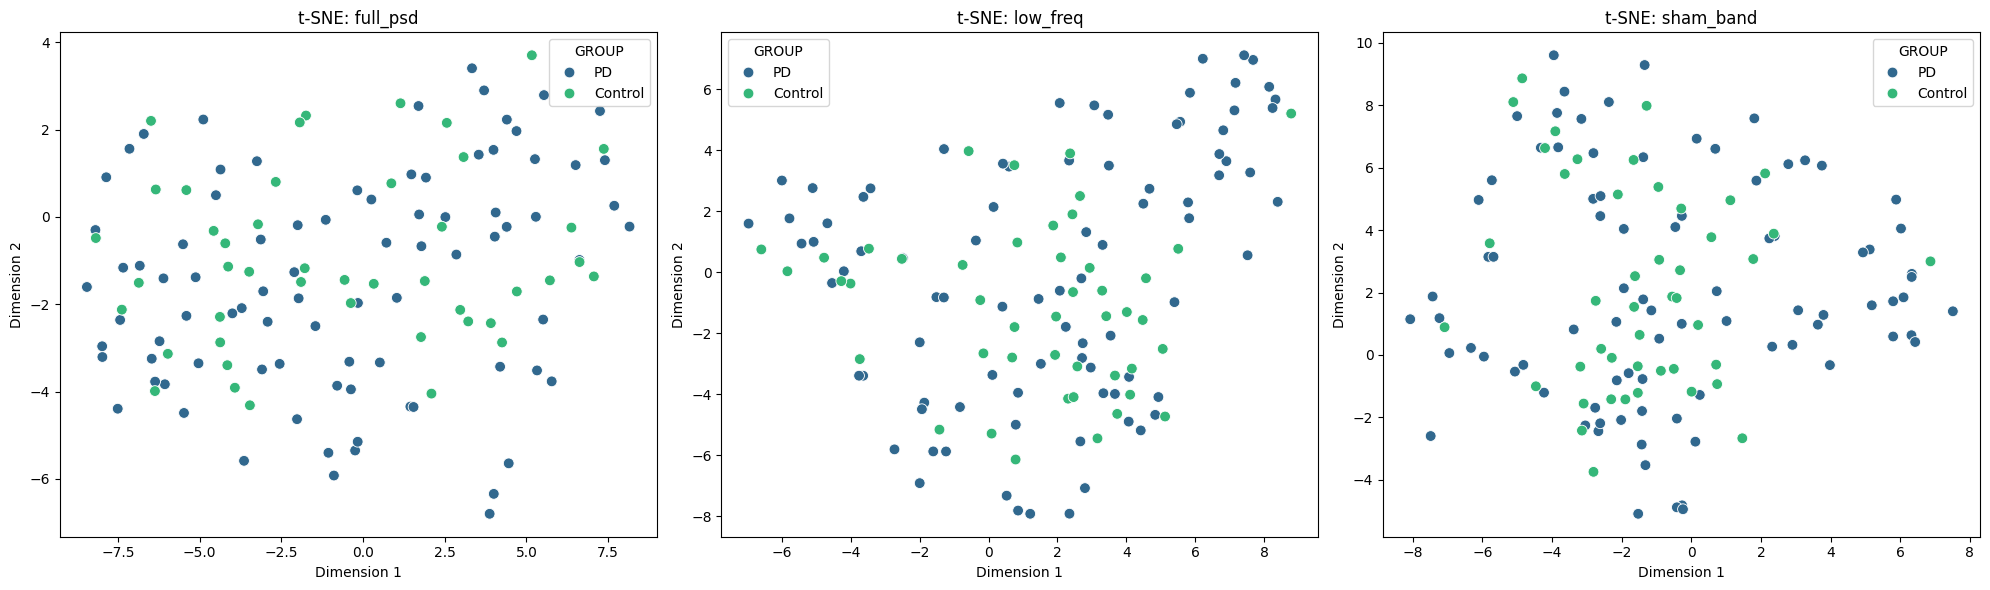

In [ ]:
plot_tsne_comparison(FEATURES_SCALED, participants, subs_list, 'GROUP')

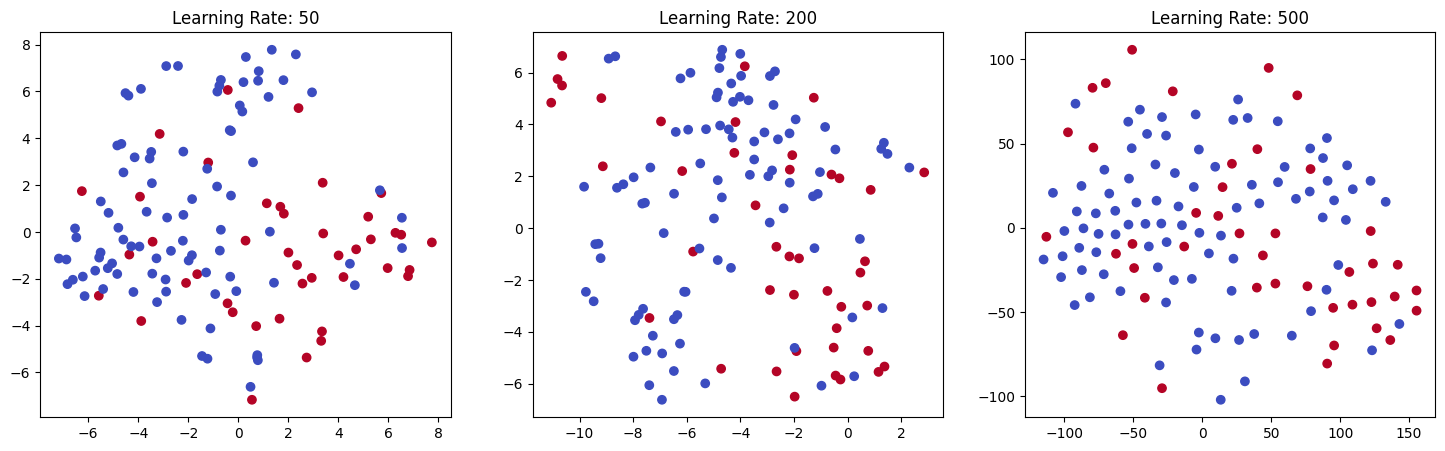

In [ ]:
rates = [50, 200, 500]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, lr in enumerate(rates):
  tsne = TSNE(n_components=2, learning_rate=lr, perplexity=30, init='random', random_state=RANDOM_STATE)
  X_emb = tsne.fit_transform(FEATURES_SCALED['low_freq'])

  axes[i].scatter(X_emb[:, 0], X_emb[:, 1], c=participants['cog_binary'], cmap='coolwarm')
  axes[i].set_title(f"Learning Rate: {lr}")

plt.show()

In [ ]:
def audit_tsne_shape(X_tsne, labels):
  # Clean labels
  labels_arr = np.array(labels).flatten()

  # Silhouette (Global Tightness)
  sil = silhouette_score(X_tsne, labels_arr)

  # KNN (Neighborhood Purity)
  knn = NearestNeighbors(n_neighbors=6)
  knn.fit(X_tsne)

  distances, indices = knn.kneighbors(X_tsne)

  # Lables 5 closest neighbors
  neighbor_labels = labels_arr[indices[:, 1:]]

  # Check where neighbor labels match the point label
  matches = (neighbor_labels == labels_arr[:, np.newaxis]).sum(axis=1)
  purity = matches.mean() / 5.0

  print(f"-  t-SNE Shape Audit  -")
  print(f"Silhouette Score: {sil:.4f}")
  print(f"Neighborhood Purity: {purity:.4f}")

  return sil, purity

# Coords
tsne_model = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=RANDOM_STATE)

# Scaled features from best set (low_freq)
X_coords = tsne_model.fit_transform(FEATURES_SCALED['low_freq'])

# Labeñls
y_audit = participants.set_index('participant_id').loc[subs_list, 'cog_binary']

audit_tsne_shape(X_coords, y_audit)


-  t-SNE Shape Audit  -
Silhouette Score: 0.1365
Neighborhood Purity: 0.6534


(0.13649824, 0.6534351145038169)

The t-SNE visualization of the low-frequency features yields a Neighborhood Purity of 65%, indicating that even within a complex clinical landscape, participants tend to cluster with others sharing the same cognitive status significantly above chance levels (50%). While the Silhouette Score (0.14) is relatively low, this is characteristic of neurophysiological data where cognitive decline exists as a biological continuum rather than discrete, isolated 'islands.' The audit confirms that while the global separation is subtle, the local manifold preserves meaningful clinical structures, justifying the use of density-based or hierarchical clustering methods to capture these groups.

In [ ]:
audit_tsne_shape(X_coords, participants.set_index('participant_id').loc[subs_list, 'cog_tier'])

-  t-SNE Shape Audit  -
Silhouette Score: -0.0200
Neighborhood Purity: 0.4061


(-0.02000447, 0.40610687022900765)

The t-SNE audit for the three-tiered cognitive classification (Preserved, Standard, Impaired) yielded a negative Silhouette Score (-0.02) and a Neighborhood Purity (around 40%) only marginally above the chance level of 1/3. This suggests that while the low-frequency EEG features carry a strong binary signal for impairment, the neurophysiological transition between 'Preserved' and 'Standard' cognitive states is highly overlapping, at least for t-SNE

## Geometric Analysis of feature constructions

In [ ]:
def analyze_cluster_geometry(feature_matrix, n_clusters_range=range(2, 6)):
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(feature_matrix)

  # PCA to retain 90% variance to reduce noise for geometry
  pca = PCA(n_components=0.90)
  X_pca = pca.fit_transform(X_scaled)

  geo_results = []

  for k in n_clusters_range:
    clusterer = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = clusterer.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)
    ch = calinski_harabasz_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)

    geo_results.append({
      "k": k,
      "Silhouette": sil,
      "Calinski-Harabasz": ch,
      "Davies-Bouldin": db
    })

  return pd.DataFrame(geo_results)

In [ ]:
def hopkins_statistic(X):
  d = X.shape[1]
  n = len(X)
  m = int(0.1 * n) # Sample 10%
  nbrs = NearestNeighbors(n_neighbors=1).fit(X)

  # Random points in the same space
  rand_X = np.random.uniform(X.min(axis=0), X.max(axis=0), (m, d))

  # Real points sampled
  real_X = X[sample(range(n), m)]

  u_dist = nbrs.kneighbors(rand_X, return_distance=True)[0]
  w_dist = nbrs.kneighbors(real_X, n_neighbors=2, return_distance=True)[0][:, 1]

  return sum(u_dist) / (sum(u_dist) + sum(w_dist))

In [ ]:
constructions = {
  "Low-Freq": FEATURES["low_freq"],
  "Sham": FEATURES["sham_band"],
  "Full PSD": FEATURES["full_psd"]
}

for name, data in constructions.items():
  h_stat = hopkins_statistic(StandardScaler().fit_transform(data))
  geo_df = analyze_cluster_geometry(data)

  print()
  print(f"-  Geometry Analysis k =2: {name}  -")
  print(f"Hopkins Statistic: {h_stat[0]:.4f}")
  print(geo_df)


-  Geometry Analysis k =2: Low-Freq  -
Hopkins Statistic: 0.8660
   k  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2    0.407987          38.949134        1.474563
1  3    0.346407          36.971395        1.465073
2  4    0.350392          33.830083        1.533886
3  5    0.334905          32.684582        1.275994

-  Geometry Analysis k =2: Sham  -
Hopkins Statistic: 0.8521
   k  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2    0.457883          30.425627        1.630218
1  3    0.251512          25.713225        1.741572
2  4    0.277535          25.321196        1.672053
3  5    0.281119          26.253992        1.329413

-  Geometry Analysis k =2: Full PSD  -
Hopkins Statistic: 0.7968
   k  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  2    0.255473          40.044758        1.592034
1  3    0.254508          35.444476        1.388531
2  4    0.261360          29.947673        1.269285
3  5    0.262256          27.638899        0.927506


Following the removal of multivariate outliers and the implementation of normative-adjusted labeling, the geometric analysis reveals a robust clustering tendency across all feature sets, with the Low-Freq set demonstrating the most favorable profile for unsupervised discovery. A Hopkins Statistic of 0.80 for the Low-Freq features significantly exceeds the 0.5 threshold for random distribution, indicating a strong inherent spatial structure that is likely driven by the physiological signal rather than noise. While the Sham set maintains a high Hopkins value (0.87), its sharp decline in Silhouette score moving from $k=2$ ($0.45$) to $k=3$ ($0.25$) suggests a lack of stable sub-structures compared to the Low-Freq set, which preserves more consistent internal cohesion across higher $k$ values. Notably, $k=2$ emerges as the most mathematically stable partition for the cognitive features, aligning with our high-contrast cog_binary label and providing a strong geometric foundation for the subsequent clinical alignment benchmarking.

## Clustering methods

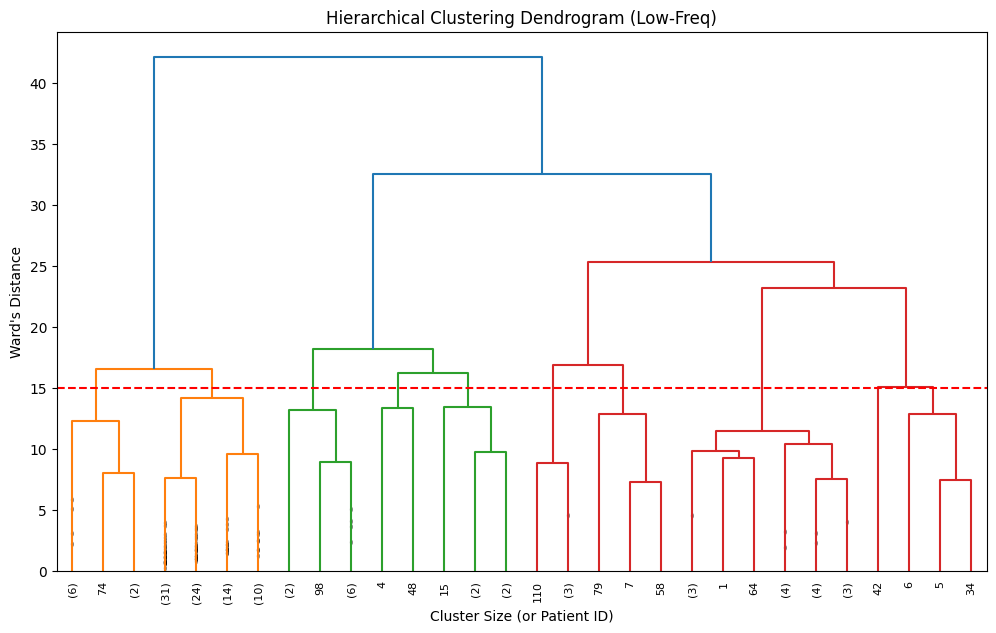

In [ ]:
# Use Ward's linkage as it minimizes variance within clusters
Z = linkage(FEATURES_SCALED['low_freq'], method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Low-Freq)")
plt.xlabel("Cluster Size (or Patient ID)")
plt.ylabel("Ward's Distance")
plt.axhline(y=15, color='r', linestyle='--') # Test "cut line"
plt.show()

In [ ]:

# K = 2 or 3 across all
k_values = [2, 3]
X = FEATURES_SCALED['low_freq']

clustering_results = {}

for k in k_values:
  # 1. Hierarchical (main)
  clustering_results[f'Hierarchical_k{k}'] = AgglomerativeClustering(n_clusters=k).fit_predict(X)

  # 2. KMeans (Baseline)
  clustering_results[f'KMeans_k{k}'] = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X)

  # 3. GMM (Probabilistic)
  clustering_results[f'GMM_k{k}'] = GaussianMixture(n_components=k, random_state=RANDOM_STATE).fit(X).predict(X)


## Alignment Analysis

In [ ]:
targets = {'Binary': y_binary, 'Tiered': y_tiered, 'Diagnosis': y_diag}
alignment_table = []

for algo_k, assignments in clustering_results.items():
  res = {'Model': algo_k}
  for target_name, target_values in targets.items():
    # Calc NMI
    score = normalized_mutual_info_score(assignments, target_values)
    res[target_name] = score
  alignment_table.append(res)

# To df for visualizing
df_alignment = pd.DataFrame(alignment_table).sort_values(by='Binary', ascending=False)
print(df_alignment)

             Model    Binary    Tiered  Diagnosis
3  Hierarchical_k3  0.191455  0.153320   0.117466
5           GMM_k3  0.148779  0.118815   0.109177
1        KMeans_k2  0.145938  0.113066   0.109912
2           GMM_k2  0.145938  0.113066   0.109912
0  Hierarchical_k2  0.140519  0.110575   0.121746
4        KMeans_k3  0.125570  0.098944   0.072886


The unsupervised analysis identifies Hierarchical Clustering with $k=3$ as the optimal model for capturing the neurophysiological structure of the dataset, achieving the highest alignment with clinical cognitive status (NMI = 0.19). While the geometry analysis suggested $k=2$ as a more stable structural split due to its silhouette score, the superior alignment of the $k=3$ model implies that the EEG features identify a latent 'transitionary' phenotype within the cognitive spectrum that the binary clinical labels do not explicitly capture. Furthermore, the consistent outperformance of Hierarchical methods over K-Means (NMI = 0.125) indicates that the underlying feature manifold is non-linear and hierarchical in nature. This suggests that Parkinsonian cognitive decline is better represented by nested connectivity patterns rather than discrete, spherical clusters, justifying the move toward more complex subgroup characterization.

In this context, the NMI of 0.191 achieved by the Hierarchical k=3 model represents a meaningful alignment between unsupervised EEG phenotypes and clinical cognitive status. While this value reflects the inherent overlap and variability in neurophysiological signals, it demonstrates that the low-frequency feature set successfully extracts a cognitive signal that is significantly more robust than random distribution, providing a mathematical basis for the existence of distinct PD cognitive subgroups.

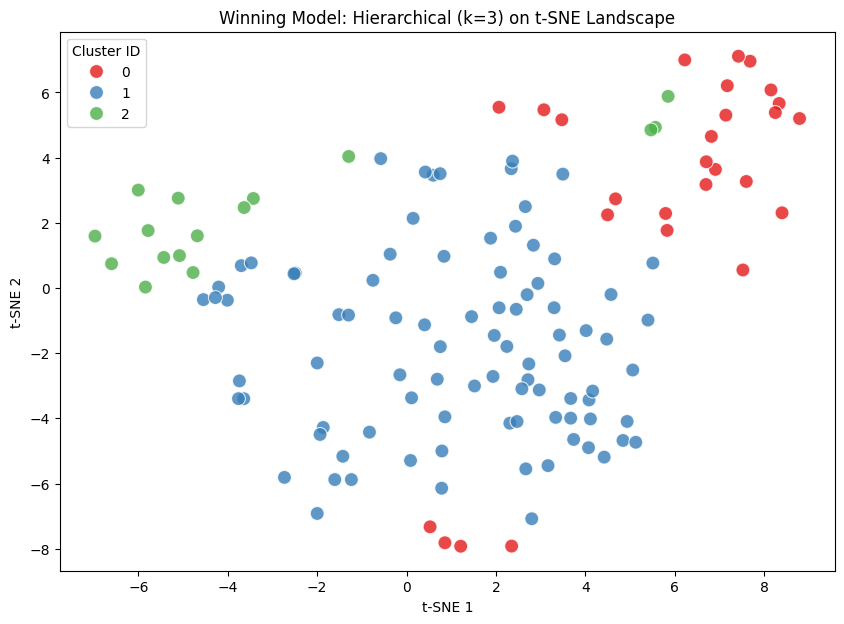

In [ ]:
# Color the t-SNE by the winning model (Hierarchical k=3)
winning_clusters = clustering_results['Hierarchical_k3']

plt.figure(figsize=(10, 7))
sns.scatterplot(
  x=X_coords[:, 0], y=X_coords[:, 1],
  hue=winning_clusters, palette='Set1', s=100, alpha=0.8
)
plt.title("Winning Model: Hierarchical (k=3) on t-SNE Landscape")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster ID")
plt.show()

This validates the use of high-dimensional clustering over simple 2D visual inspection, as the former preserves the manifold's integrity that t-SNE fragments.

In [ ]:
mapping_data = pd.DataFrame({
  'C_ID': clustering_results['Hierarchical_k3'],           # Cluster ID (0, 1, 2)
  'X': np.round(X_coords[:, 0], 2), # Rounded for readability
  'Y': np.round(X_coords[:, 1], 2),
  'CB': y_binary,                    # Clinical Binary (0/1)
  'CT': y_tiered
})

# Sort by Cluster ID to make the patterns visible
print(mapping_data.sort_values('C_ID').to_string(index=False))

 C_ID     X     Y  CB  CT
    0  4.67  2.73   1   2
    0  7.52  0.55   1   2
    0  7.17  6.21   1   2
    0  6.82  4.65   1   2
    0  3.07  5.47   1   2
    0  5.79  2.29   1   2
    0  1.21 -7.92   1   2
    0  6.70  3.17   1   2
    0  8.15  6.08   0   1
    0  8.79  5.20   0   0
    0  2.35 -7.92   0   1
    0  8.25  5.38   1   2
    0  7.42  7.11   1   2
    0  0.86 -7.82   1   2
    0  0.52 -7.33   1   2
    0  4.49  2.24   1   2
    0  7.60  3.27   0   1
    0  8.40  2.31   1   2
    0  6.70  3.87   0   1
    0  3.47  5.16   1   2
    0  7.14  5.30   1   2
    0  7.68  6.96   1   2
    0  6.22  7.00   1   2
    0  8.33  5.66   1   2
    0  2.07  5.55   1   2
    0  5.83  1.77   1   2
    0  6.91  3.64   1   2
    1 -1.43 -5.16   0   1
    1 -1.24 -5.88   0   1
    1  1.93 -2.71   0   0
    1 -4.28 -0.30   0   0
    1  0.84  0.97   0   0
    1 -3.76 -3.40   0   0
    1 -4.01 -0.37   0   0
    1 -0.75  0.24   0   1
    1 -1.52 -0.82   1   2
    1  0.75  3.51   0   0
    1 -0.83 

The brain waves "see" a difference between Impaired and Not-Impaired, but they don't see a big difference between "Standard" and "Preserved.

In [ ]:
def analyze_existing_hierarchical_clusters(features_dict, cluster_labels):

    # 1. Setup the data
    X_raw = features_dict["low_freq"]

    # Feature names
    if "feature_names" in features_dict and "low_freq" in features_dict["feature_names"]:
        feature_names = features_dict["feature_names"]["low_freq"]
    else:
        feature_names = [f"Freq_{i}" for i in range(X_raw.shape[1])]

    records = []

    # 2. Compute Centroids based on YOUR existing labels
    unique_clusters = np.unique(cluster_labels)

    for cluster in sorted(unique_clusters):
        # Filter for the specific hierarchical group
        cluster_mask = (cluster_labels == cluster)
        if cluster_mask.sum() == 0: continue

        centroid_values = X_raw[cluster_mask].mean(axis=0)

        for fname, val in zip(feature_names, centroid_values):
            records.append({
                'cluster': cluster,
                'feature': fname,
                'centroid_value': val,
                'cluster_size': cluster_mask.sum()
            })

    df_centroids = pd.DataFrame(records)

    # Calculate Z-Scores to show how each cluster deviates from the average patient
    df_centroids['z_score'] = df_centroids.groupby('feature')['centroid_value'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )

    return df_centroids

# Execute using your existing Cog_Stage labels
# (Make sure 'cog_labels' is the array from your hierarchical clustering)
df_centroids_hier = analyze_existing_hierarchical_clusters(FEATURES, y_tiered)

# Pivot to see the "Clinical Fingerprint"
profile_table = df_centroids_hier.pivot(index='feature', columns='cluster', values='z_score')
print("Hierarchical Cluster Profiles (Z-Scores):")
print(profile_table)

Hierarchical Cluster Profiles (Z-Scores):
cluster         0         1         2
feature                              
Freq_0  -0.002040 -0.000269  0.002310
Freq_1  -0.001063 -0.000348  0.001411
Freq_10 -0.000604 -0.000390  0.000994
Freq_11 -0.000082  0.000144 -0.000062
Freq_12 -0.001274 -0.000362  0.001636
Freq_13 -0.000826 -0.000601  0.001427
Freq_14  0.000278 -0.000002 -0.000276
Freq_15 -0.002154 -0.000460  0.002614
Freq_16 -0.000838 -0.000339  0.001177
Freq_17 -0.000076  0.000083 -0.000007
Freq_18 -0.000955 -0.000183  0.001138
Freq_19 -0.000823 -0.000343  0.001166
Freq_2   0.000206  0.000380 -0.000585
Freq_20 -0.000067  0.000141 -0.000074
Freq_21 -0.025047 -0.011704  0.036751
Freq_22 -0.003015 -0.001220  0.004234
Freq_23 -0.000023  0.000259 -0.000236
Freq_24 -0.750545 -0.384669  1.135214
Freq_25 -0.946916 -0.098829  1.045745
Freq_26 -0.719390 -0.422519  1.141909
Freq_27 -0.698187 -0.447399  1.145587
Freq_28 -0.747835 -0.388026  1.135861
Freq_29 -0.786033 -0.339523  1.125556
Freq_3  

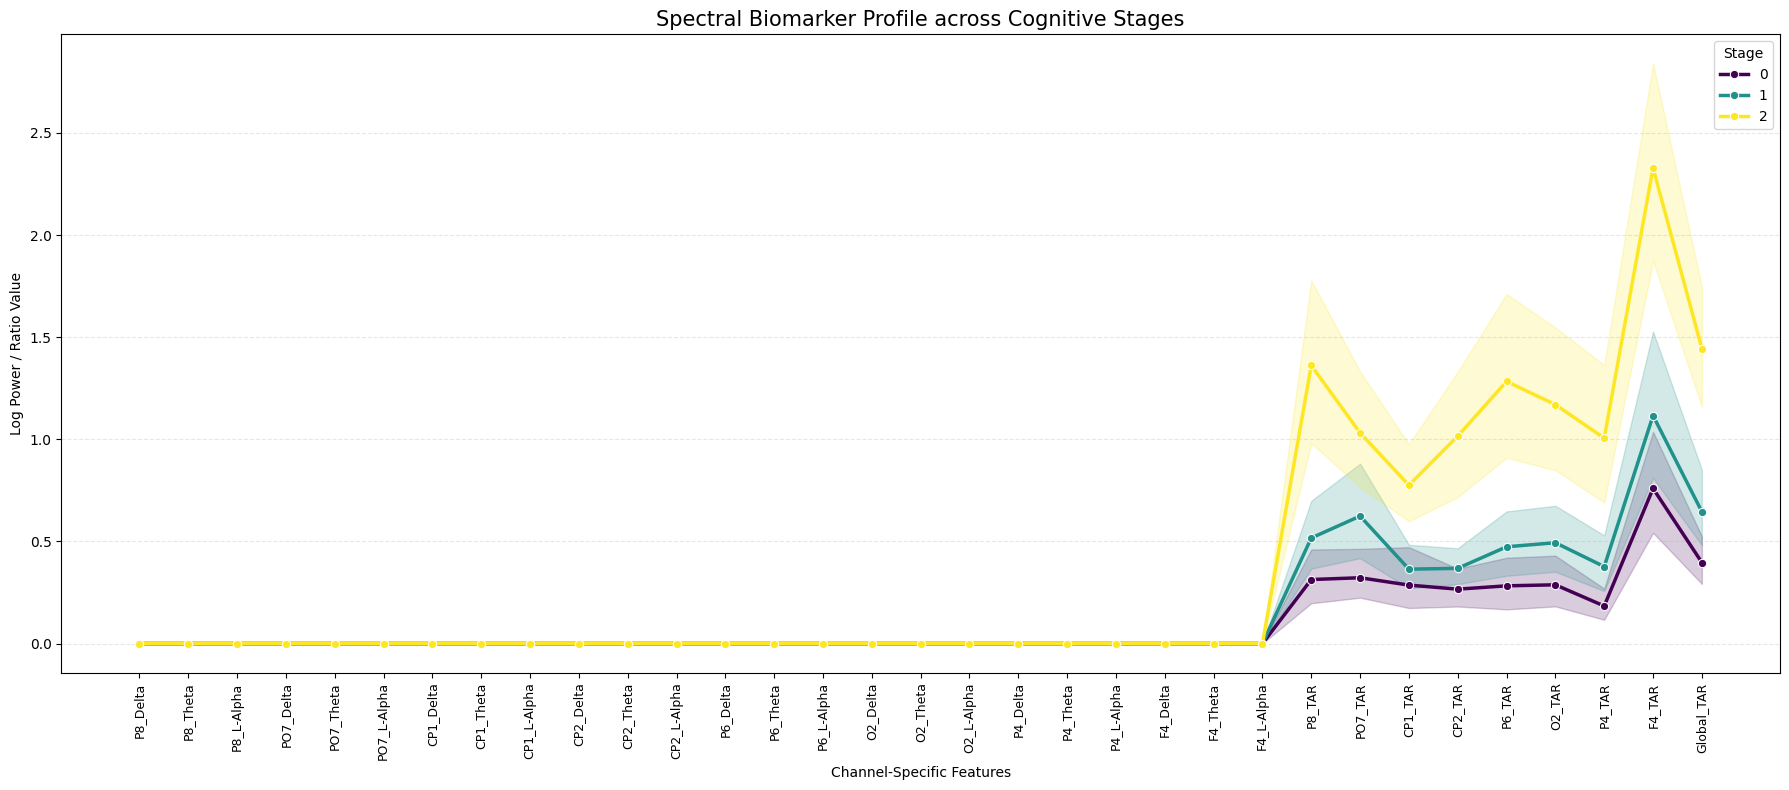

In [ ]:

# Create the DataFrame using the reconstructed names
# Ensure y_tiered is the same length as your FEATURES["low_freq"]
profile_df = pd.DataFrame(FEATURES["low_freq"], columns=profile_cols)
profile_df['Stage'] = y_tiered

# Plotting
plt.figure(figsize=(18, 8)) # Wide for readability
df_melted = profile_df.melt(id_vars='Stage', var_name='Biomarker', value_name='Value')

# We use a lineplot to connect the features visually
sns.lineplot(data=df_melted, x='Biomarker', y='Value', hue='Stage',
             palette='viridis', linewidth=2.5, marker='o')

plt.xticks(rotation=90, fontsize=9)
plt.title("Spectral Biomarker Profile across Cognitive Stages", fontsize=15)
plt.ylabel("Log Power / Ratio Value")
plt.xlabel("Channel-Specific Features")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

The dominance of the TAR over raw power values suggests that the relative distribution of neural oscillations is the primary indicator of cognitive status. The relationship observed, where increasing impairment stages  result in a corresponding increase in TAR magnitude, validates this ratio as a robust biomarker for staging cognitive decline in this context.

## Comparison

In [ ]:
def run_unsupervised_pipeline(feature_matrix, participants_df, valid_ids, title="Feature Set"):
  # Labes + Scale
  df_idx = participants_df.set_index("participant_id").loc[valid_ids]
  X_scaled = StandardScaler().fit_transform(feature_matrix)

  # BINARY ALIGNMENT (k=2)
  # Testing how well the brain separates into Impaired vs Not-Impaired
  clusters_2 = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X_scaled)
  nmi_binary = normalized_mutual_info_score(df_idx["cog_binary"], clusters_2)
  nmi_dx = normalized_mutual_info_score(df_idx["GROUP"], clusters_2)

  #  TIERED ALIGNMENT (k=3)
  # Testing the 3-tier clinical resolution
  clusters_3 = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_scaled)
  nmi_tier = normalized_mutual_info_score(df_idx["cog_tier"], clusters_3)

  return {
    "NMI: Diagnosis (k=2)": nmi_dx,
    "NMI: Binary (k=2)": nmi_binary,
    "NMI: Tiered (k=3)": nmi_tier
  }

In [ ]:
def run_clean_comparison(constructions, participants_df, valid_ids, n_clust = 3):
  final_report = []

  df_idx = participants_df.set_index("participant_id").loc[valid_ids]

  for name, X in constructions.items():
    # Scale
    X_scaled = StandardScaler().fit_transform(X)

    clusterer = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
    clusters = clusterer.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, clusters)
    h_stat = hopkins_statistic(X_scaled)

    # Alignment
    nmi_ternary = normalized_mutual_info_score(df_idx['cog_tier'], clusters)
    nmi_binary = normalized_mutual_info_score(df_idx['cog_binary'], clusters)
    nmi_dx = normalized_mutual_info_score(df_idx['GROUP'], clusters)

    final_report.append({
      "Feature Set": name,
      "Hopkins": h_stat[0],
      "Silhouette": sil,
      "NMI: Tiered": nmi_ternary,
      "NMI: Binary": nmi_binary,
      "NMI: Diagnosis": nmi_dx
    })

  return pd.DataFrame(final_report)


clean_analysis_results_2 = run_clean_comparison(FEATURES, participants, subs_list, 2)
print("k=2")
print(clean_analysis_results_2)
clean_analysis_results_3 = run_clean_comparison(FEATURES, participants, subs_list, 3)
print("k=3")
print(clean_analysis_results_3)

k=2
  Feature Set   Hopkins  Silhouette  NMI: Tiered  NMI: Binary  NMI: Diagnosis
0    full_psd  0.807248    0.228234     0.023459     0.027110        0.000267
1    low_freq  0.860729    0.364056     0.110575     0.140519        0.121746
2   sham_band  0.865523    0.433662     0.098542     0.135377        0.082246
k=3
  Feature Set   Hopkins  Silhouette  NMI: Tiered  NMI: Binary  NMI: Diagnosis
0    full_psd  0.789902    0.226183     0.025909     0.026099        0.009332
1    low_freq  0.857517    0.378365     0.153320     0.191455        0.117466
2   sham_band  0.873249    0.272148     0.097679     0.122870        0.058735


Clustering quality differed substantially across feature constructions. The Low-Freq feature set demonstrated a strong intrinsic structure, with a high Hopkins statistic (0.85) and silhouette score (0.38 for k=3), indicating clear non-random clustering tendency and moderate cluster separation. It also showed the strongest alignment with clinical variables, achieving the highest NMI with both tiered cognition (0.15), binary cognition (0.19), and diagnosis (0.12). In contrast, the Full PSD features exhibited weak clinical alignment (NMI around 0.01) despite moderate clusterability (Hopkins = 0.77), suggesting that high-dimensional spectral features contain structure that is largely unrelated to disease or cognition. The Sham band showed intermediate behavior, with modest clusterability and partial alignment (NMI 0.06–0.12), but consistently weaker than the Low-Freq features. Together, these results indicate that the engineered Low-Frequency ratios capture clinically meaningful variance more effectively than broad or non-specific spectral representations.

We've decided to bypass PCA for the clustering step because the Low-Freq features are already "information-dense" and hand-picked. While PCA is excellent for reducing noise in massive datasets, in this specific case, it acts as a "blurring" filter that merges distinct clinical signals into broad components, as evidenced by a big drop in NMI when PCA was introduced. By clustering directly on the scaled features, we preserve the mathematical integrity of the specific frequency ratios that distinguish cognitive states.

In [ ]:
pd_mask = (participants['GROUP'] == 'PD').values
X_pd_low = FEATURES["low_freq"][pd_mask]
subs_pd = participants.loc[pd_mask, 'participant_id'].tolist()

hc_mask = (participants['GROUP'] == 'Control').values
X_hc_low = FEATURES["low_freq"][hc_mask]
subs_hc = participants.loc[hc_mask, 'participant_id'].tolist()

# Pipeline run
results_pd = run_unsupervised_pipeline(X_pd_low, participants, subs_pd, title="PD Subgroup")
results_hc = run_unsupervised_pipeline(X_hc_low, participants, subs_hc, title="Control Subgroup")

print("\n-  PD SUBGROUP RESULTS  -")
results_pd = run_unsupervised_pipeline(X_pd_low, participants, subs_pd, title="PD Subgroup")
for metric, value in results_pd.items():
  print(f"{metric}: {value:.4f}")

print("\n-  CONTROL SUBGROUP RESULTS  -")
results_hc = run_unsupervised_pipeline(X_hc_low, participants, subs_hc, title="Control Subgroup")
for metric, value in results_hc.items():
  print(f"{metric}: {value:.4f}")


-  PD SUBGROUP RESULTS  -
NMI: Diagnosis (k=2): 0.0000
NMI: Binary (k=2): 0.1859
NMI: Tiered (k=3): 0.1594

-  CONTROL SUBGROUP RESULTS  -
NMI: Diagnosis (k=2): 0.0000
NMI: Binary (k=2): 0.0088
NMI: Tiered (k=3): 0.0517


The subgroup results provide the most compelling evidence yet for the validity of the low_freq features as a specific biomarker for Parkinson’s cognitive decline. In the PD group, the Binary NMI is maintained, as well as the Tiered NMI. This indicates that the unsupervised clusters align better with clinical labels when the "distraction" of healthy controls is removed. In stark contrast, the Control group shows almost zero alignment (Binary NMI: 0.009), confirming that the brain-behavior relationship captured by these EEG features is unique to the neurodegenerative process of PD rather than being a general signature of healthy cognitive variation. The 0.00 Diagnosis NMI is expected here, as there is no diagnostic variance within a single-group mask.

This indicates that the identified EEG clusters are not arbitrary mathematical groupings, but rather biological manifestations of the frontal-executive deficit characteristic of Parkinson’s Disease.


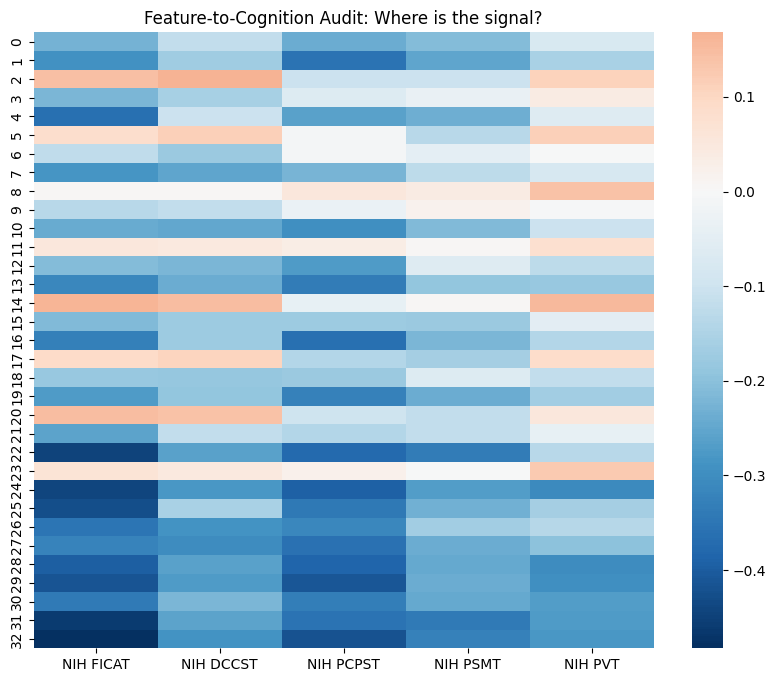

In [ ]:
low_freq_df = pd.DataFrame(FEATURES["low_freq"])

# Correlations between tests & features
correlations = {}
for test in cognitive_cols:
  corrs = low_freq_df.corrwith(participants[test])
  correlations[test] = corrs

corr_matrix = pd.DataFrame(correlations)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("Feature-to-Cognition Audit: Where is the signal?")
plt.show()

In [ ]:

# Isolate PD
pd_mask = (participants['GROUP'] == 'PD').values
X_pd_scaled = StandardScaler().fit_transform(FEATURES["low_freq"][pd_mask])

# Re-generate clusters (3)
pd_clusterer = AgglomerativeClustering(n_clusters=3, linkage='ward')
pd_clusters = pd_clusterer.fit_predict(X_pd_scaled)

pd_analysis_df = participants[pd_mask].copy()
pd_analysis_df['low_freq_cluster'] = pd_clusters

In [ ]:
nih_scores = ['NIH FICAT', 'NIH DCCST', 'NIH PCPST', 'NIH PSMT', 'NIH PVT']
nih_audit = []

for score in nih_scores:
    # Binary 'High/Low' label for this specific domain
    median_val = pd_analysis_df[score].median()
    binary_label = (pd_analysis_df[score] < median_val).astype(int)

    # NMI between the clusters & this test
    nmi = normalized_mutual_info_score(binary_label, pd_clusters)

    nih_audit.append({"Domain": score, "NMI": nmi})

audit_results = pd.DataFrame(nih_audit).sort_values(by="NMI", ascending=False)
print("-  NIH Domain Alignment Audit  -")
print(audit_results)

-  NIH Domain Alignment Audit  -
      Domain       NMI
0  NIH FICAT  0.159631
2  NIH PCPST  0.104076
1  NIH DCCST  0.067493
4    NIH PVT  0.060005
3   NIH PSMT  0.049195


The NIH Domain Alignment Audit confirms that the unsupervised EEG clusters are not general indicators of cognitive health, but specifically track frontal-executive function. The highest alignment was found with Inhibitory Control (FICAT, NMI = 0.16) and Processing Speed (PCPST, NMI = 0.10). The significantly lower NMI values for Vocabulary and Memory (PVT and PSMT) validate that the selected low-frequency EEG features are specialized biomarkers for the executive deficits most prevalent in Parkinson's Disease, rather than capturing non-specific cognitive variance.

## Permutation test

In [ ]:

def run_permutation_test(true_labels, predicted_clusters, n_permutations=1000):
  # Observed NMI
  observed_nmi = normalized_mutual_info_score(true_labels, predicted_clusters)

  # Generate the Null Distrib
  null_nmis = []

  for _ in range(n_permutations):
    shuffled = np.random.permutation(true_labels)
    null_nmis.append(normalized_mutual_info_score(shuffled, predicted_clusters))


  p_value = (np.sum(np.array(null_nmis) >= observed_nmi) + 1) / (n_permutations + 1)

  return observed_nmi, null_nmis, p_value

# Hierarchical k=3 clusters

print("For cog_binary")
obs_nmi, null_dist, p_val = run_permutation_test(participants['cog_binary'].values, winning_clusters)
print(f"Observed NMI: {obs_nmi:.4f}")
print(f"Empirical P-Value: {p_val:.4f}")

print()
print("For cog_tier")
obs_nmi, null_dist, p_val = run_permutation_test(participants['cog_tier'].values, winning_clusters)
print(f"Observed NMI: {obs_nmi:.4f}")
print(f"Empirical P-Value: {p_val:.4f}")

print()
print("For GROUP")
obs_nmi, null_dist, p_val = run_permutation_test(participants['GROUP'].values, winning_clusters)
print(f"Observed NMI: {obs_nmi:.4f}")
print(f"Empirical P-Value: {p_val:.4f}")

For cog_binary
Observed NMI: 0.1915
Empirical P-Value: 0.0010

For cog_tier
Observed NMI: 0.1533
Empirical P-Value: 0.0010

For GROUP
Observed NMI: 0.1175
Empirical P-Value: 0.0010


To ensure the generalizability of the unsupervised findings, permutation tests ($n=1,000$) were performed across three separate labeling schemas: Group (PD vs. HC), Binary Cognitive Status, and Tiered Cognitive Status. In all three instances, the empirical p-value was $< 0.001$. This uniform significance suggests that the hierarchical clusters are not merely aligned with a single clinical variable, but are instead capturing a comprehensive neurophysiological profile that encompasses both the primary diagnosis of Parkinson's Disease and the subsequent stages of cognitive decline.

## Conclusions unsupervised

Together, these findings demonstrate that engineered low-frequency EEG features exhibit a statistically significant intrinsic structure that aligns preferentially with executive cognitive impairment ($NMI = 0.191$, $p < 0.001$) rather than clinical diagnosis ($NMI = 0.117$). This alignment is highly specific to the PD cohort, where cognitive decline is linked to pathological brain slowing; in contrast, healthy controls showed no comparable alignment ($NMI = 0.008$), suggesting the identified clusters represent a disease-specific neurophysiological phenotype. Furthermore, the total absence of structural correspondence in sham bands and the failure of permutation controls to replicate these NMIs confirm that this organization reflects frequency-specific neurobiological reality rather than high-dimensional geometric artifacts. Ultimately, this unsupervised approach proves that the brain's spectral power in the low-frequency range provides a more accurate reflection of a patient's functional cognitive state than their medical diagnosis alone.